In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import talib
import pynance as pn

plt.style.use('default')

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

In [3]:
df = pd.read_csv('../data/AAPL.csv')

df.head

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [4]:
df.shape

(3774, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [6]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.set_index('Date', inplace=True)

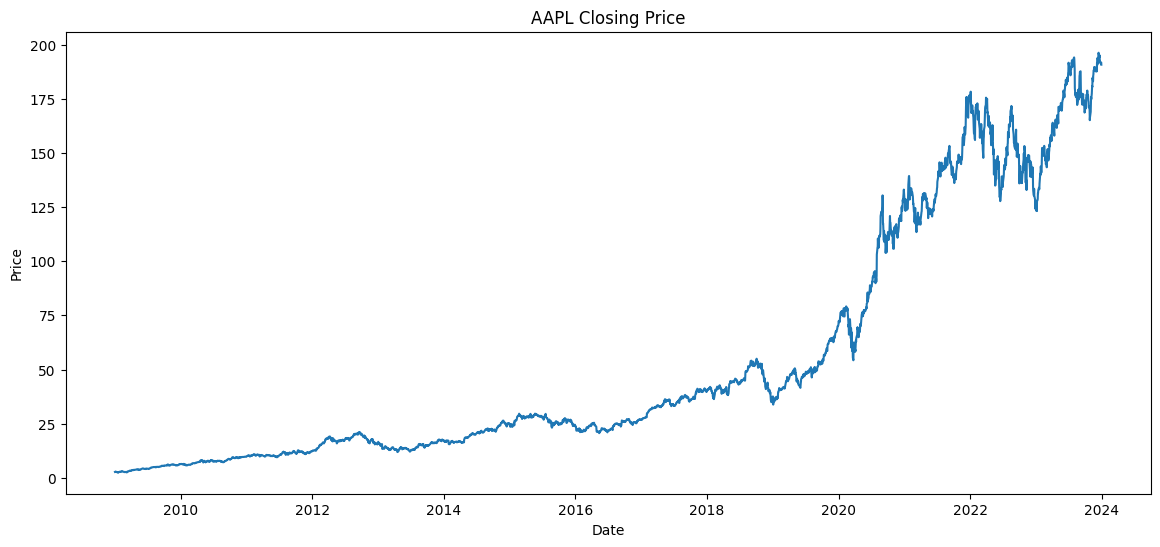

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

### AAPL Closing Price Insight

The AAPL stock price demonstrates a strong long-term upward trend, indicating sustained company growth and positive investor sentiment over time.

Several periods of increased volatility and short-term corrections are visible, particularly during major market events such as the COVID-19 pandemic period around 2020.

The sharp acceleration in price after 2020 suggests strong bullish momentum and increased market confidence in the technology sector.

In [10]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)

df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

In [11]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

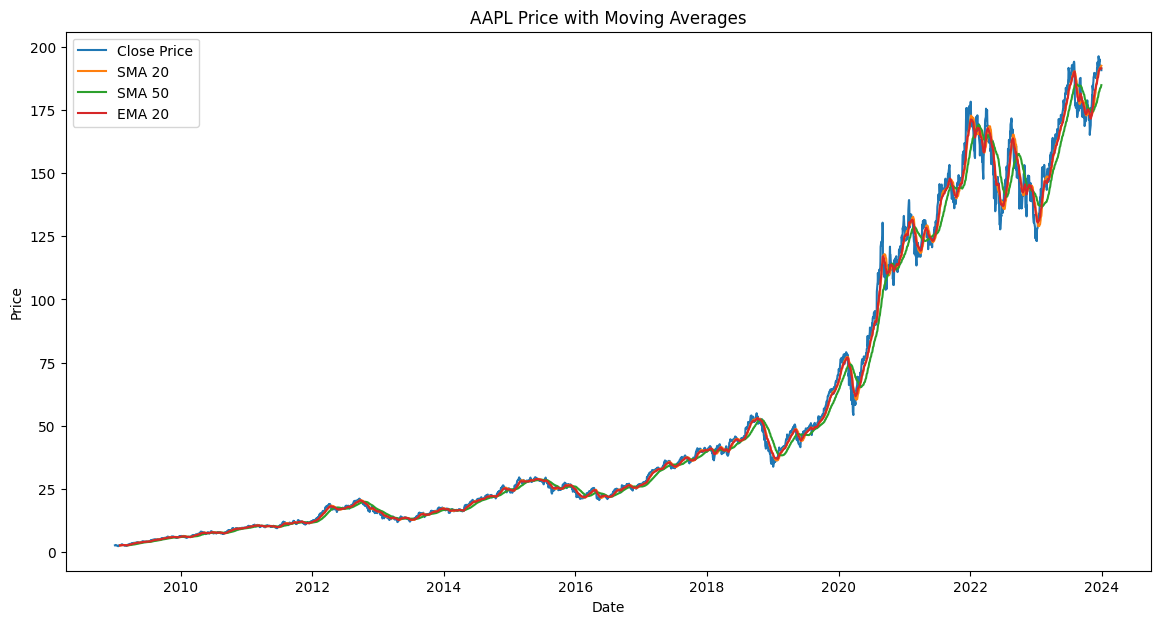

In [12]:
plt.figure(figsize=(14,7))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.plot(df.index, df['SMA_50'], label='SMA 50')
plt.plot(df.index, df['EMA_20'], label='EMA 20')

plt.title("AAPL Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

### Moving Average Insight

The moving averages smooth short-term fluctuations and help reveal the underlying trend in AAPL stock prices.

The EMA 20 reacts more quickly to recent price changes compared to the SMA indicators, making it more sensitive to short-term momentum shifts.

The SMA 50 provides a clearer view of the long-term trend direction and helps identify broader market movements.

Several crossover points between the moving averages can be observed, which may indicate potential bullish or bearish trend changes.

In [13]:
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

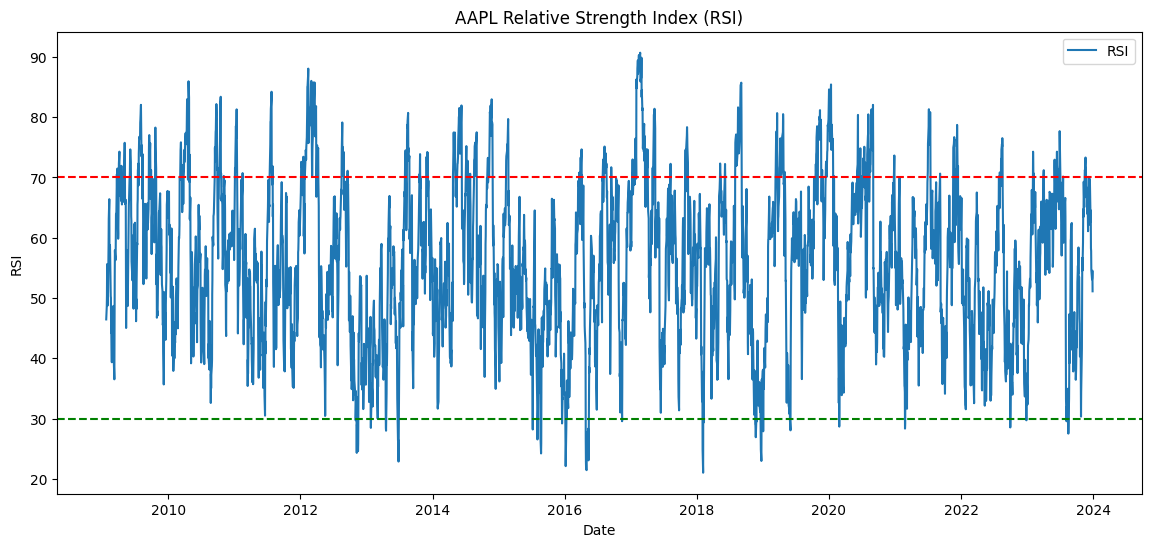

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['RSI'], label='RSI')

plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title("AAPL Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()

plt.show()

### RSI Insight

The RSI indicator fluctuates between 0 and 100 and helps identify momentum extremes in AAPL stock prices.

Periods where RSI rises above 70 suggest potentially overbought market conditions, while values below 30 indicate possible oversold conditions.

Most RSI values remain between 30 and 70, reflecting relatively balanced market momentum during normal trading periods.

Sharp RSI fluctuations may correspond to periods of increased volatility or major market events.

In [15]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

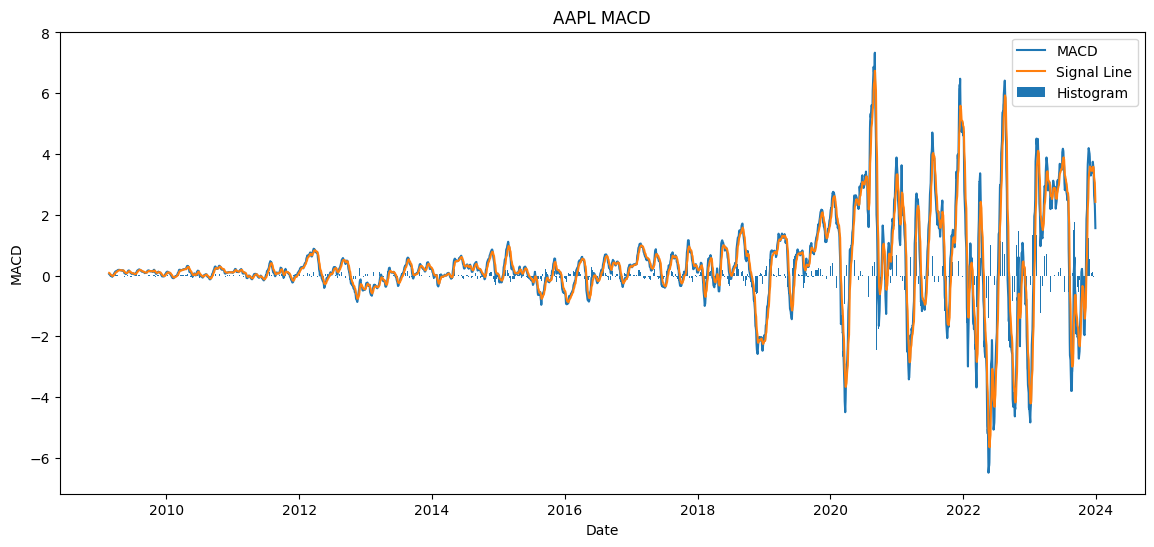

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal Line')

plt.bar(df.index, df['MACD_hist'], label='Histogram')

plt.title("AAPL MACD")
plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()

plt.show()

### MACD Insight

The MACD indicator highlights momentum shifts and potential trend reversals in AAPL stock prices.

Periods where the MACD line crosses above the signal line may indicate bullish momentum, while downward crossovers suggest bearish conditions.

The histogram reflects the strength of momentum differences between the MACD and signal lines.

Noticeably larger MACD fluctuations after 2020 indicate increased market volatility and stronger momentum swings during that period.

In [20]:
df['Daily_Return'] = df['Close'].pct_change()

df['Daily_Return'].describe()

count    3773.000000
mean        0.001289
std         0.018010
min        -0.128647
25%        -0.007547
50%         0.001062
75%         0.010770
max         0.119808
Name: Daily_Return, dtype: float64

### Daily Return Insight

The daily return analysis shows that AAPL generated a positive average daily return over the observed period, indicating long-term growth in stock value.

The standard deviation of returns suggests moderate market volatility, with noticeable fluctuations in daily performance.

Extreme minimum and maximum return values reflect periods of significant market movement, likely associated with major financial events, earnings announcements, or broader market shocks.

# Conclusion

The technical analysis of AAPL stock data revealed clear long-term upward trends alongside periods of increased volatility and momentum shifts.

Moving averages helped smooth price fluctuations and identify trend direction, while RSI and MACD provided insight into momentum strength, overbought/oversold conditions, and potential trend reversals.

Daily return analysis further highlighted the variability of stock performance and periods of significant market activity.

Overall, the computed indicators provide a strong quantitative foundation for later correlation analysis between financial news sentiment and stock price behavior.